# Board Level Strategic Insight Request
## Data Analyst: Sheena Salao
## Date of Request: 09-29-2025

Scenario

A mid-sized financial institution has been actively expanding its personal loan portfolio. However, recent shifts in customer behavior and credit risk profiles have prompted the Board of Directors to revisit the underlying factors influencing loan approvals and amounts granted. The board is particularly concerned with credit risk, profitability, and data-driven decision-making.

During a quarterly strategy meeting, the Chief Risk Officer (CRO) presents a dashboard highlighting inconsistencies in the average loan amounts issued across customer segments. Some applicants with moderate income and lower credit scores are receiving higher-than-expected loan amounts, while more qualified applicants appear to be under-leveraged.

In response, the Chairperson of the Board raises a crucial question:

"Among all the customer attributes we’ve been collecting—like income, credit score, employment history, age, debt-to-income ratio, and education level—can we clearly identify which of these factors have the strongest statistical relationship with the loan amount issued?"

The board mandates the Data Analytics Team to conduct an immediate correlation analysis to:

1. Identify which factors most strongly drive loan amounts.

2. Distinguish between statistically significant vs. insignificant variables.

3. Support future decisions about automating loan approvals, tightening risk thresholds, or tailoring products to specific customer profiles.

Create a Business Analytics Report that address the request of the board.

In [2]:
!pip install qdesc

**Loading, Organizing, and Inspecting Data**

In [3]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import qdesc as qd

# Checking current working directory
import os
print(os.getcwd())

# Load dataset
df = pd.read_excel("HypotheticalLoansData.xlsx")
df.head(10)

/content


,Income,CreditScore,EmploymentYears,DebtToIncome,Age,EducationLevel,LoanAmount
0,67450.71,746.31,22,0.27,48,Bachelor,105119.57
1,57926.04,795.47,11,0.38,59,Bachelor,104818.75
2,69715.33,630.07,16,0.37,26,Bachelor,99397.74
3,82845.45,728.15,7,0.23,29,High School,99163.53
4,56487.70,667.47,10,0.38,40,High School,80141.29
5,56487.95,675.64,28,0.24,21,Master,80524.89
6,83688.19,670.38,2,0.48,28,Bachelor,77519.47
7,71511.52,656.80,26,0.22,43,High School,86387.21
8,52957.88,702.43,5,0.32,23,Master,74900.95
9,68138.40,658.45,8,0.22,24,High School,102339.46


**Data Cleaning and Preparation**

In [15]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Basic data info and types
print("Dataset Info:")
print(df.info())


Missing Values:
Income             0
CreditScore        0
EmploymentYears    0
DebtToIncome       0
Age                0
EducationLevel     0
LoanAmount         0
dtype: int64
Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Income           500 non-null    float64
 1   CreditScore      500 non-null    float64
 2   EmploymentYears  500 non-null    int64  
 3   DebtToIncome     500 non-null    float64
 4   Age              500 non-null    int64  
 5   EducationLevel   500 non-null    object 
 6   LoanAmount       500 non-null    float64
dtypes: float64(4), int64(2), object(1)
memory usage: 27.5+ KB
None


**Descriptive Analytics**

In [16]:
# Summary statistics for numerical columns
print("Summary Statistics:")
display(df.describe())

Summary Statistics:


,Income,CreditScore,EmploymentYears,DebtToIncome,Age,LoanAmount
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,60102.569780,701.591200,14.312000,0.298900,42.544000,87561.532960
std,14718.798391,48.900041,8.517026,0.096851,12.714219,13021.297761
min,11380.990000,565.160000,0.000000,0.010000,21.000000,53960.780000
25%,49495.390000,670.235000,7.000000,0.230000,31.750000,78285.482500
50%,60191.960000,701.430000,14.000000,0.300000,42.500000,87579.970000
75%,69551.752500,732.562500,22.000000,0.360000,54.000000,96888.517500
max,117790.970000,831.620000,29.000000,0.570000,64.000000,119076.870000


In [17]:
# Descriptive statistics grouped by EducationLevel for LoanAmount
print("Grouped by EducationLevel - LoanAmount:")
qd.grp_desc(df, 'LoanAmount', 'EducationLevel')

Grouped by EducationLevel - LoanAmount:


,EducationLevel,count,mean,std,median,mad,min,max,AD_stat,crit_5%
0,Bachelor,196,88304.15,12480.19,88356.46,8512.23,55148.87,118933.66,0.21,0.77
1,High School,143,87155.92,13372.74,85927.97,8322.56,55336.11,119076.87,0.33,0.77
2,Master,108,86384.78,13692.45,87048.54,10064.15,53960.78,118226.28,0.26,0.76
3,PhD,53,88307.58,12762.66,89743.25,8897.99,56075.68,114863.34,0.20,0.74


In [18]:
# Descriptive statistics grouped by EducationLevel for Income
print("\nGrouped by EducationLevel - Income:")
qd.grp_desc(df, 'Income', 'EducationLevel')


Grouped by EducationLevel - Income:


,EducationLevel,count,mean,std,median,mad,min,max,AD_stat,crit_5%
0,Bachelor,196,60778.35,14481.55,61342.14,9154.84,20703.82,92856.83,0.35,0.77
1,High School,143,59385.95,14409.97,59479.32,9679.69,28988.37,106183.21,0.33,0.77
2,Master,108,59768.93,13495.24,60491.06,9087.56,28141.56,91385.81,0.11,0.76
3,PhD,53,60216.85,18637.13,57215.12,12001.01,11380.99,117790.97,0.63,0.74


In [19]:
# Descriptive statistics grouped by EducationLevel for CreditScore
print("\nGrouped by EducationLevel - CreditScore:")
qd.grp_desc(df, 'CreditScore', 'EducationLevel')


Grouped by EducationLevel - CreditScore:


,EducationLevel,count,mean,std,median,mad,min,max,AD_stat,crit_5%
0,Bachelor,196,700.93,50.32,701.90,31.68,565.16,831.62,0.47,0.77
1,High School,143,700.36,44.66,704.97,31.11,589.44,808.16,0.32,0.77
2,Master,108,703.90,50.55,698.26,33.38,576.42,814.94,0.39,0.76
3,PhD,53,702.67,52.23,701.30,36.52,597.91,828.00,0.22,0.74


**Normality Check**


--- Variable: Income ---
  Anderson-Darling Statistic : 0.2978
  Critical Value (@ 5.0%) : 0.7810
  Decision : Fail to Reject Null


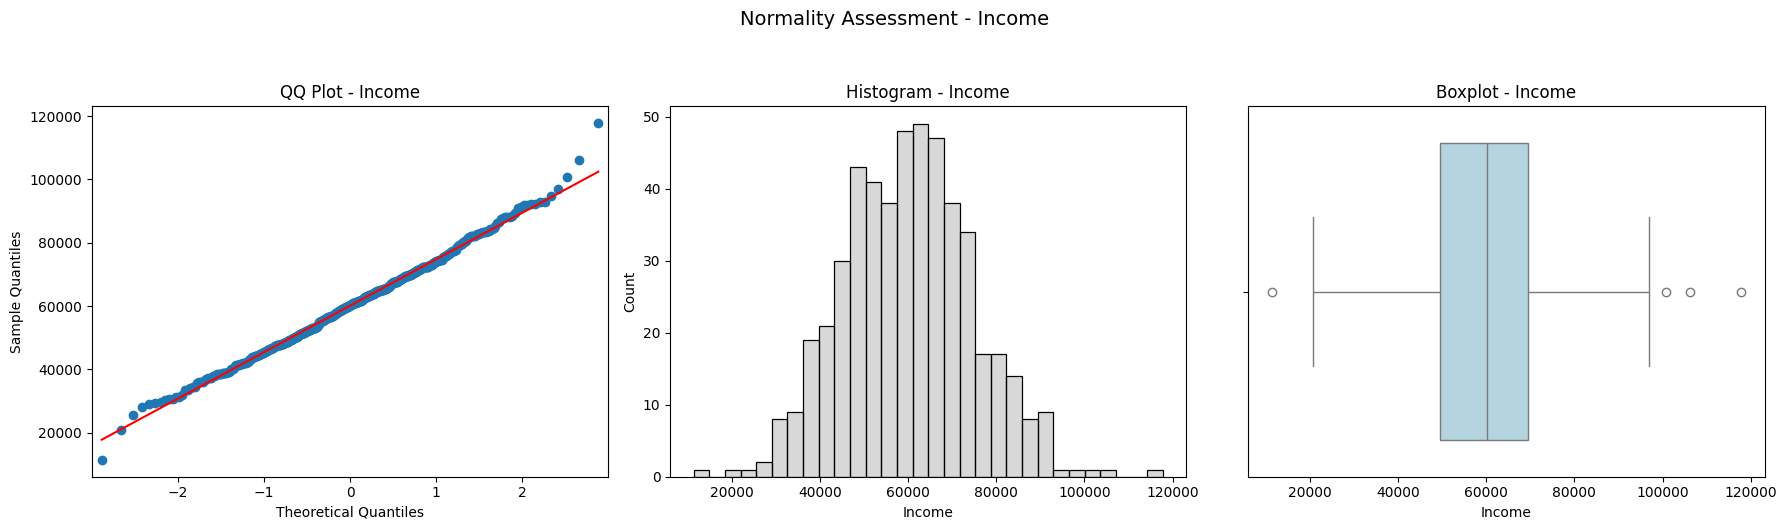


--- Variable: CreditScore ---
  Anderson-Darling Statistic : 0.2349
  Critical Value (@ 5.0%) : 0.7810
  Decision : Fail to Reject Null


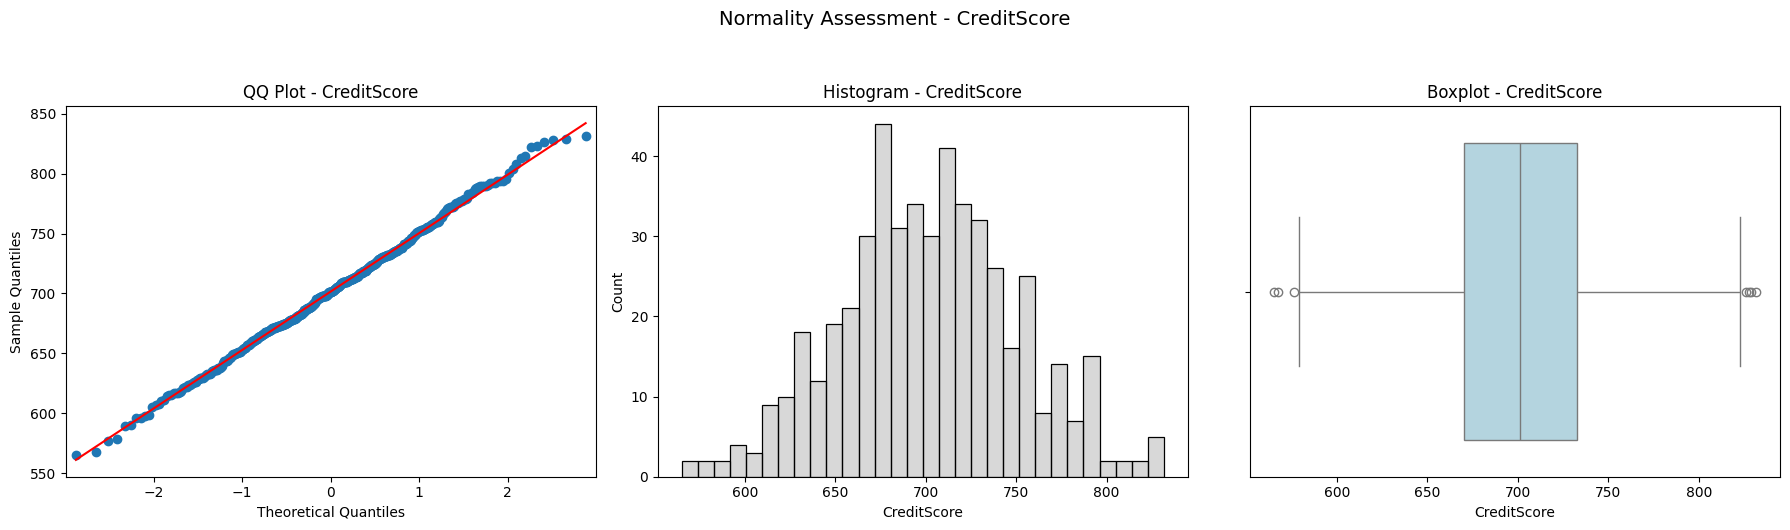


--- Variable: EmploymentYears ---
  Anderson-Darling Statistic : 5.2192
  Critical Value (@ 5.0%) : 0.7810
  Decision : Reject Null


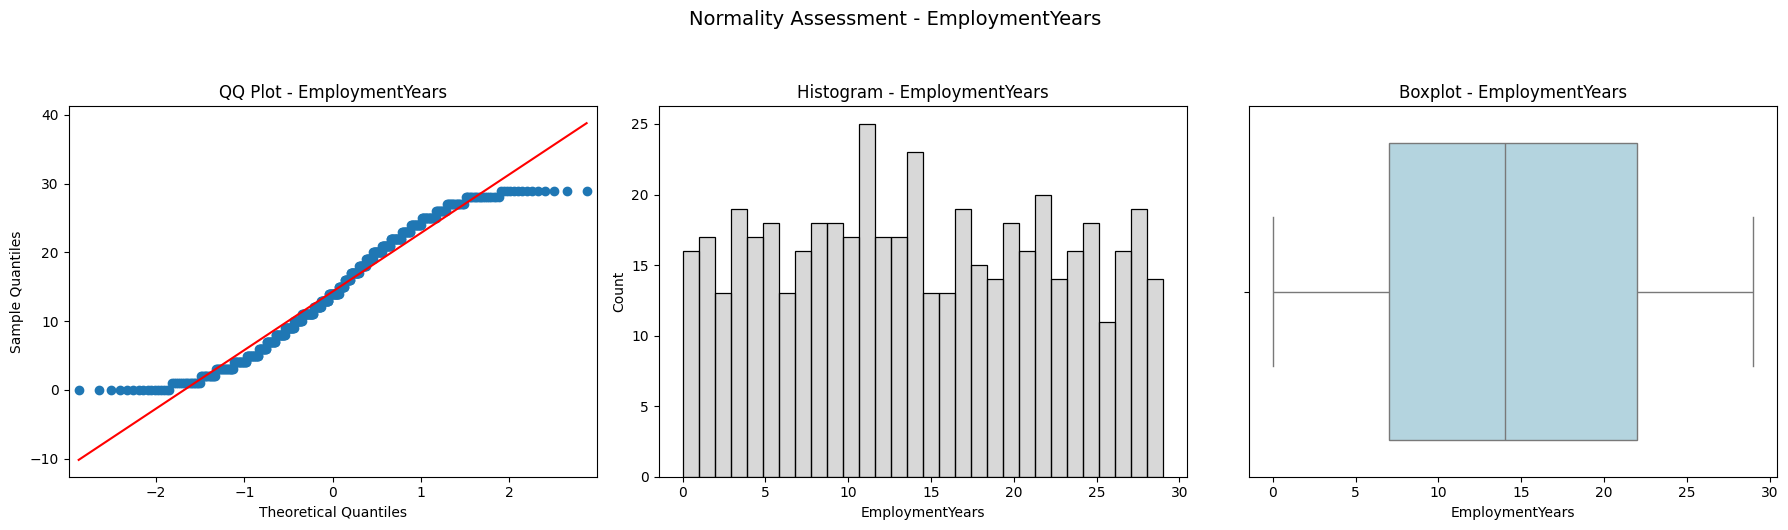


--- Variable: DebtToIncome ---
  Anderson-Darling Statistic : 0.4250
  Critical Value (@ 5.0%) : 0.7810
  Decision : Fail to Reject Null


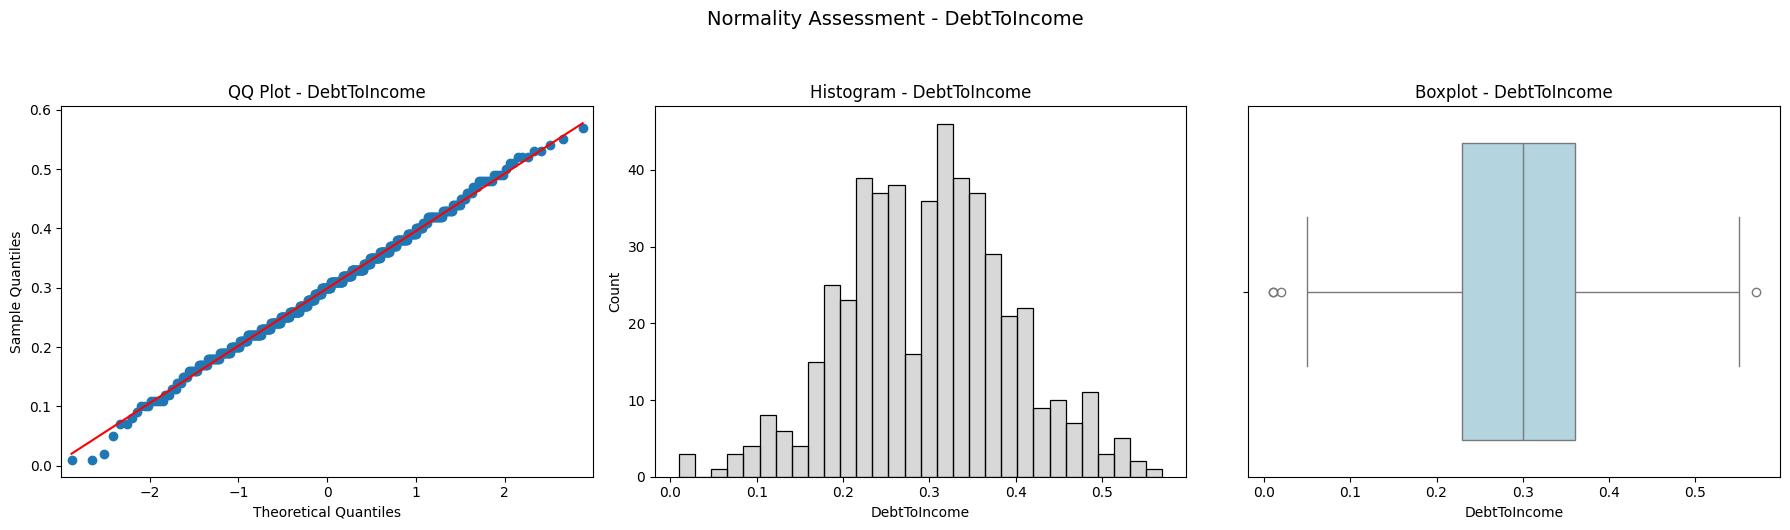


--- Variable: Age ---
  Anderson-Darling Statistic : 6.4294
  Critical Value (@ 5.0%) : 0.7810
  Decision : Reject Null


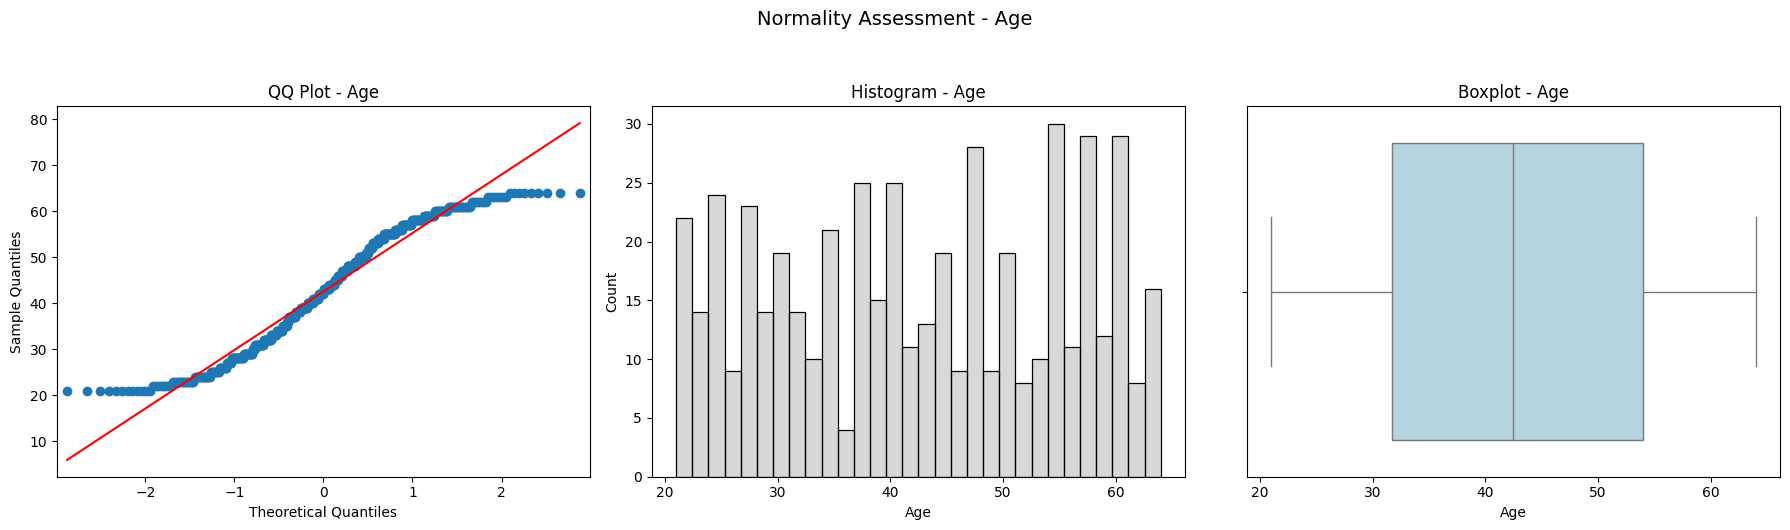


--- Variable: LoanAmount ---
  Anderson-Darling Statistic : 0.2794
  Critical Value (@ 5.0%) : 0.7810
  Decision : Fail to Reject Null


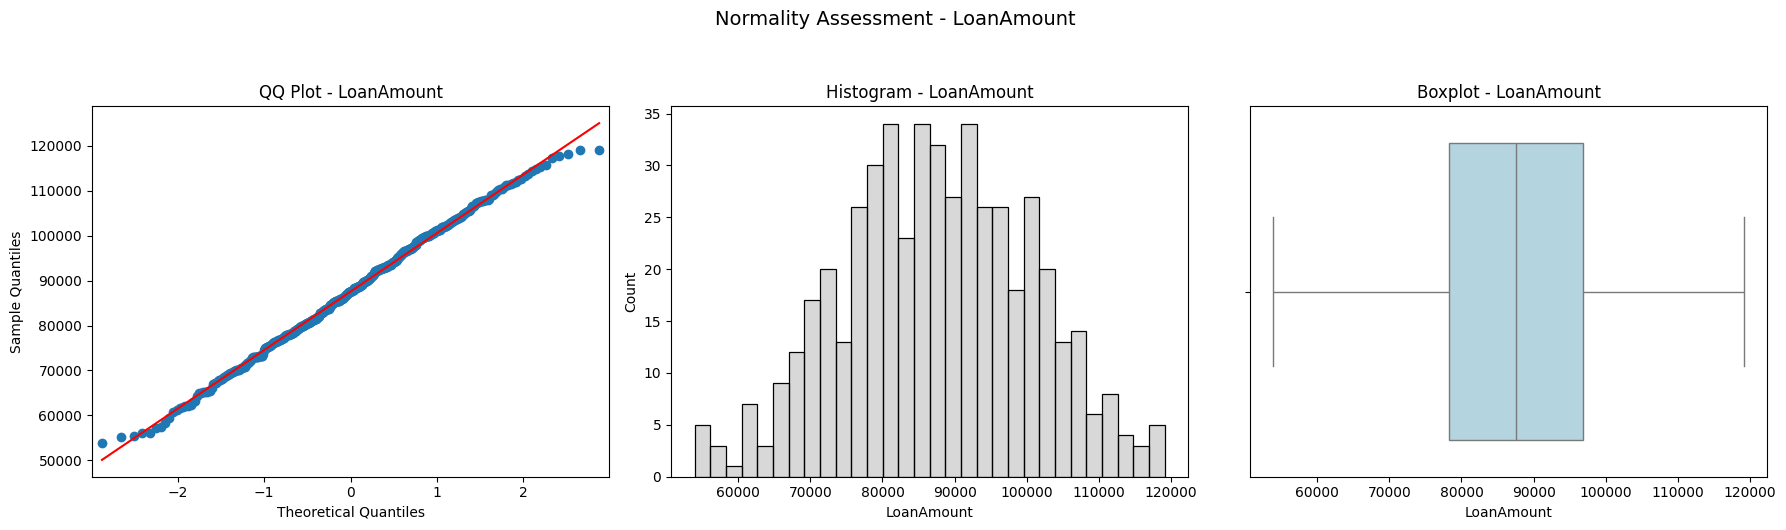

In [27]:
# Normality check dashboard (AD-test + histogram, qqplot)
qd.normcheck_dashboard(df)

**Exploratory Data Analysis (EDA)**

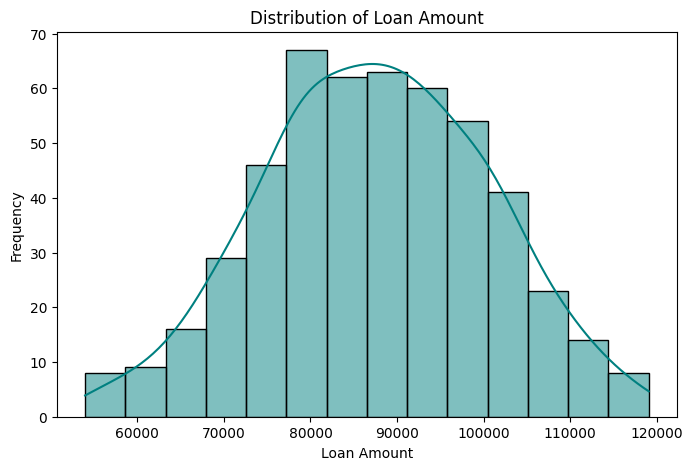

In [21]:
# Distribution of the Target Variable (Loan Amount)
plt.figure(figsize=(8,5))
sns.histplot(df['LoanAmount'], kde=True, color='teal')
plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()

Loan Amount by EducationLevel


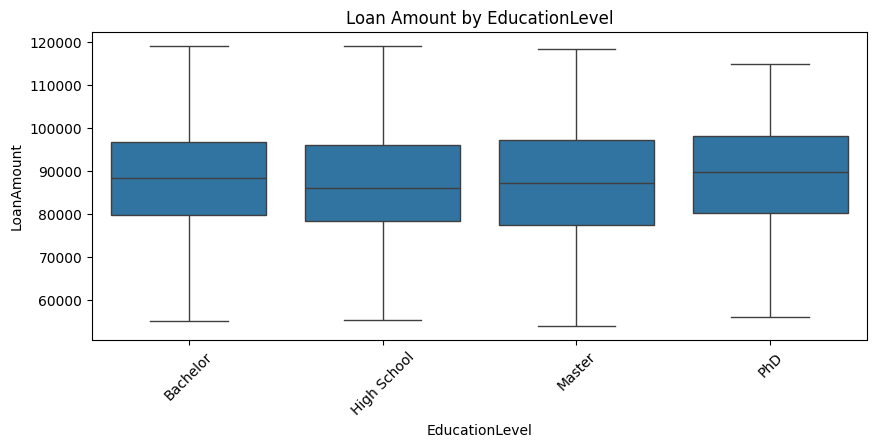

In [26]:
# Boxplots for Loan by Education
categorical_cols = ['EducationLevel']
target = 'LoanAmount'

if any(x for x in categorical_cols):
    for cat in categorical_cols:
        print(f"Loan Amount by {cat}")
        plt.figure(figsize=(10,4))
        sns.boxplot(x=cat, y=target, data=df)
        plt.title(f"Loan Amount by {cat}")
        plt.xticks(rotation=45)
        plt.show()

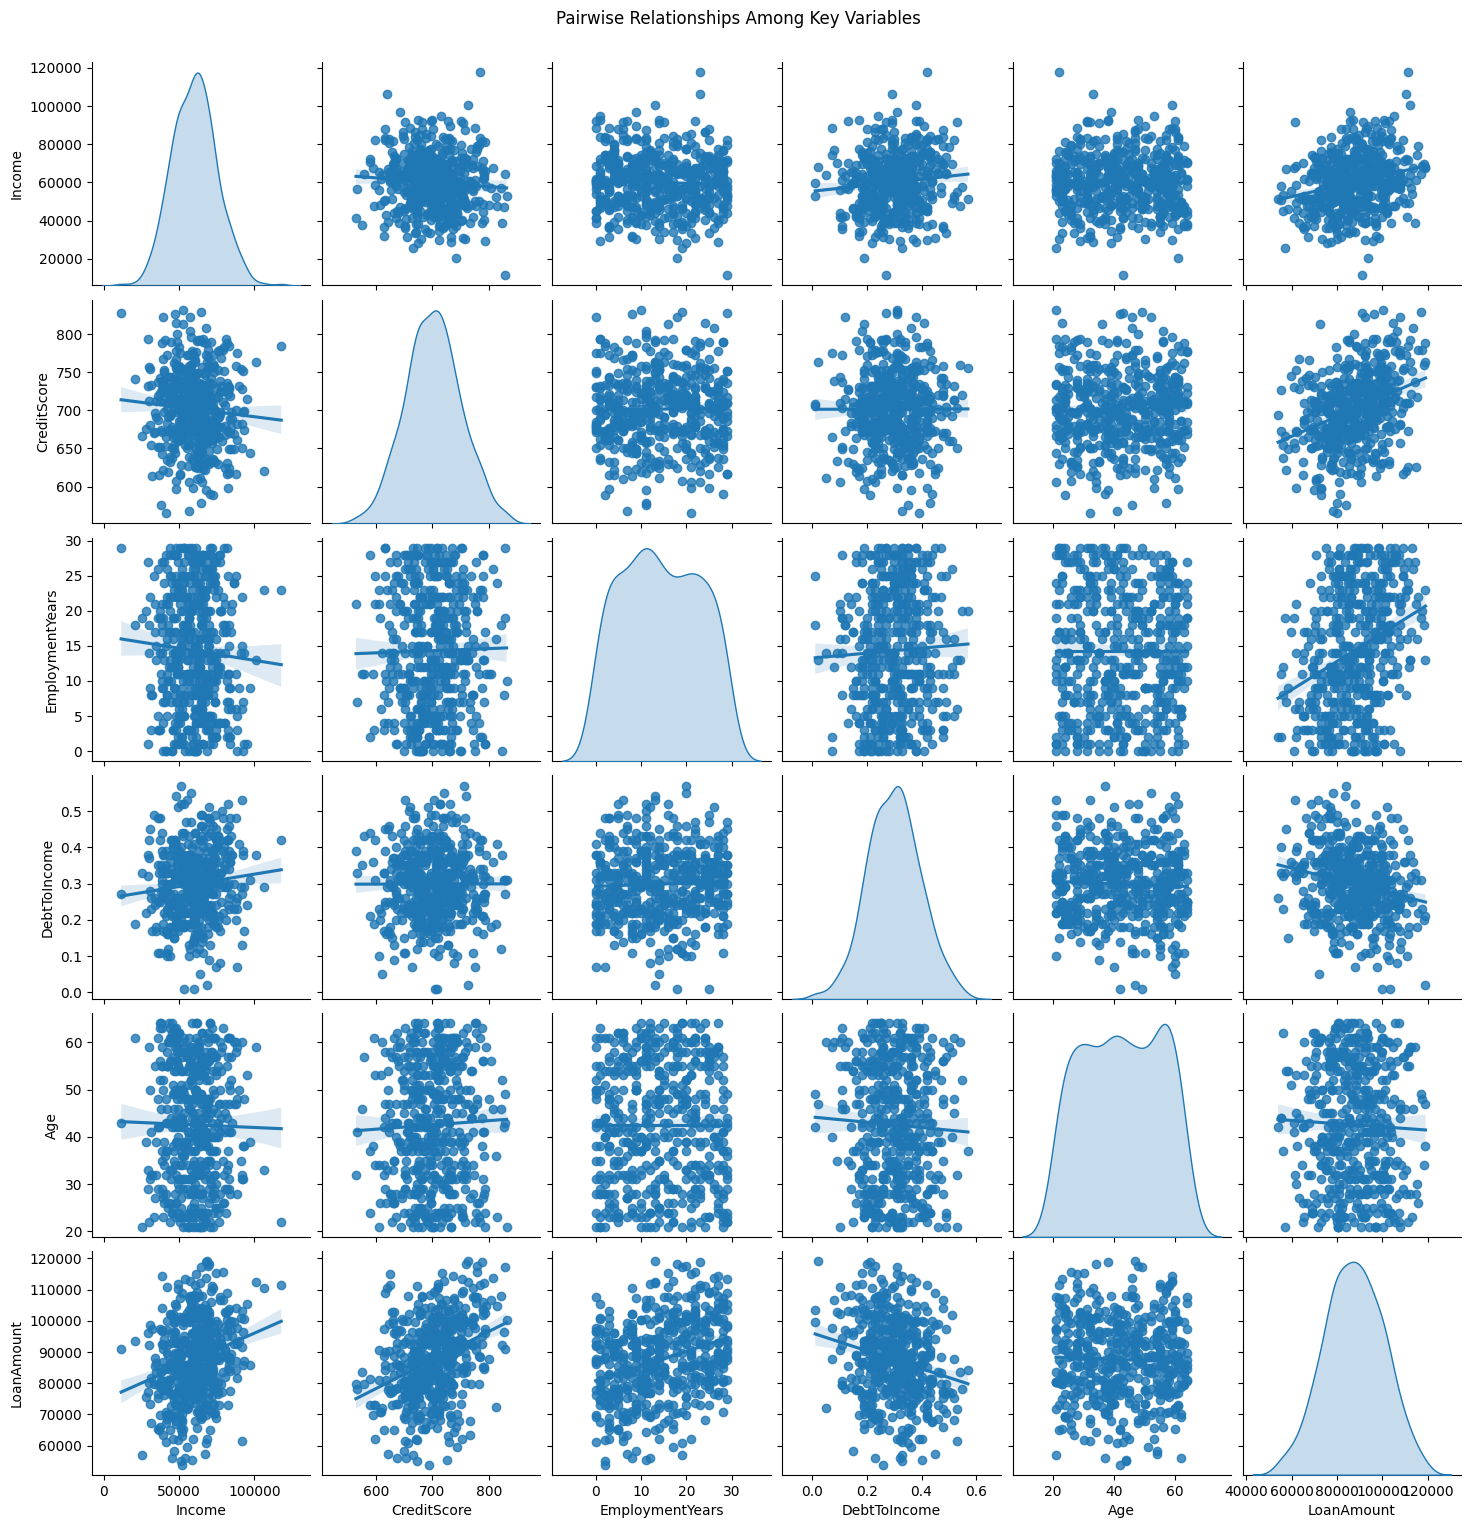

In [22]:
# Pairplot of Key Numerical Features vs. Loan Amount
sns.pairplot(df, vars=['Income','CreditScore','EmploymentYears','DebtToIncome','Age','LoanAmount'],
             kind="reg", diag_kind="kde")
plt.suptitle("Pairwise Relationships Among Key Variables", y=1.02)
plt.show()

**Correlation Analysis**

In [47]:
# Compute Spearman correlations (non-parametric)
spearman_corr = df.corr(method='spearman', numeric_only=True)['LoanAmount'].sort_values(ascending=False)
print("Spearman Correlation with Loan Amount:")
display(spearman_corr)

Spearman Correlation with Loan Amount:


,LoanAmount
LoanAmount,1.000000
CreditScore,0.340454
EmploymentYears,0.301337
Income,0.226108
Age,-0.037659
DebtToIncome,-0.198562


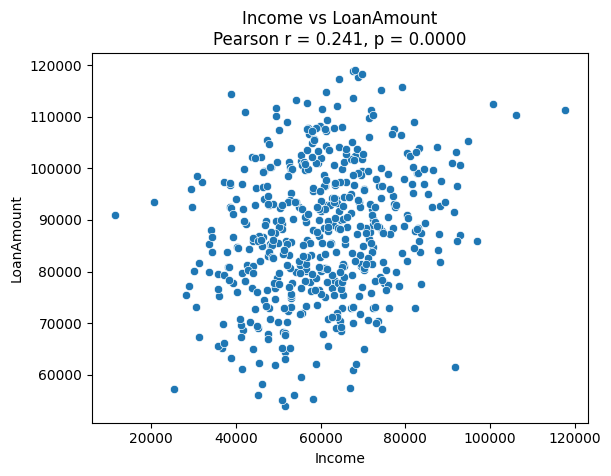

Income vs LoanAmount → Pearson r = 0.241, p-value = 0.0000



In [55]:
# Income vs LoanAmount
from scipy.stats import pearsonr

r, p = pearsonr(df['Income'], df['LoanAmount'])
sns.scatterplot(x=df['Income'], y=df['LoanAmount'])
plt.title(f"Income vs LoanAmount\nPearson r = {r:.3f}, p = {p:.4f}")
plt.xlabel("Income")
plt.ylabel("LoanAmount")
plt.show()
print(f"Income vs LoanAmount → Pearson r = {r:.3f}, p-value = {p:.4f}\n")

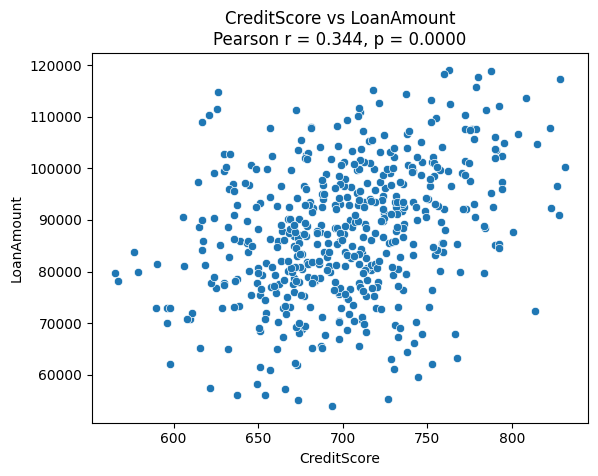

CreditScore vs LoanAmount → Pearson r = 0.344, p-value = 0.0000



In [56]:
# CreditScore vs LoanAmount
r, p = pearsonr(df['CreditScore'], df['LoanAmount'])
sns.scatterplot(x=df['CreditScore'], y=df['LoanAmount'])
plt.title(f"CreditScore vs LoanAmount\nPearson r = {r:.3f}, p = {p:.4f}")
plt.xlabel("CreditScore")
plt.ylabel("LoanAmount")
plt.show()
print(f"CreditScore vs LoanAmount → Pearson r = {r:.3f}, p-value = {p:.4f}\n")


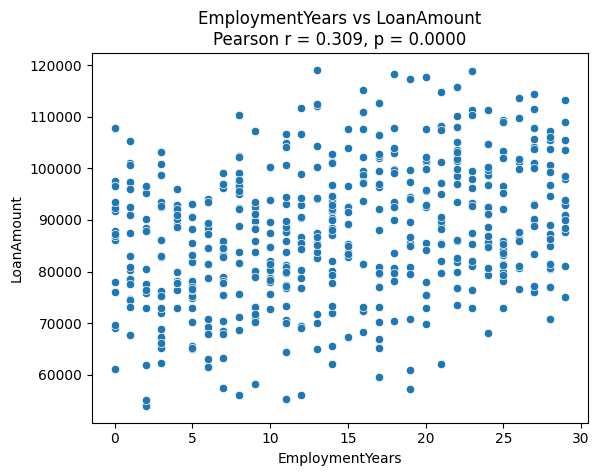

EmploymentYears vs LoanAmount → Pearson r = 0.309, p-value = 0.0000



In [57]:
# EmploymentYears vs LoanAmount
r, p = pearsonr(df['EmploymentYears'], df['LoanAmount'])
sns.scatterplot(x=df['EmploymentYears'], y=df['LoanAmount'])
plt.title(f"EmploymentYears vs LoanAmount\nPearson r = {r:.3f}, p = {p:.4f}")
plt.xlabel("EmploymentYears")
plt.ylabel("LoanAmount")
plt.show()
print(f"EmploymentYears vs LoanAmount → Pearson r = {r:.3f}, p-value = {p:.4f}\n")


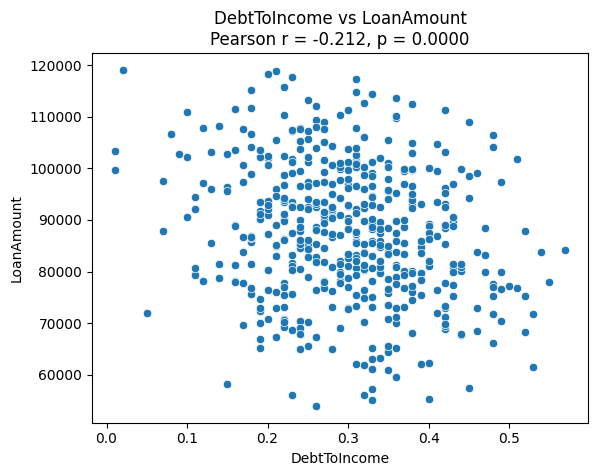

DebtToIncome vs LoanAmount → Pearson r = -0.212, p-value = 0.0000



In [58]:
# DebtToIncome vs LoanAmount
r, p = pearsonr(df['DebtToIncome'], df['LoanAmount'])
sns.scatterplot(x=df['DebtToIncome'], y=df['LoanAmount'])
plt.title(f"DebtToIncome vs LoanAmount\nPearson r = {r:.3f}, p = {p:.4f}")
plt.xlabel("DebtToIncome")
plt.ylabel("LoanAmount")
plt.show()
print(f"DebtToIncome vs LoanAmount → Pearson r = {r:.3f}, p-value = {p:.4f}\n")

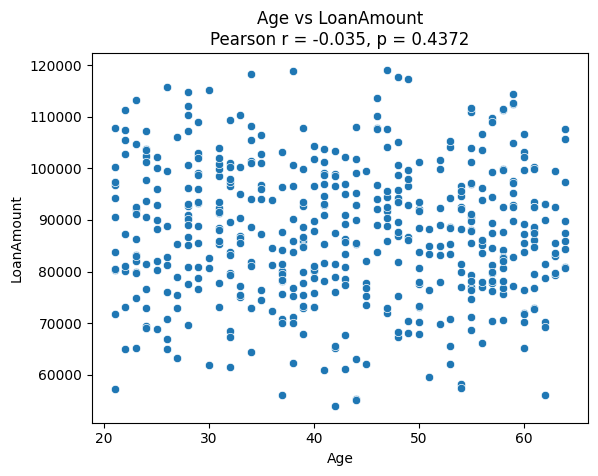

Age vs LoanAmount → Pearson r = -0.035, p-value = 0.4372



In [59]:
# Age vs LoanAmount
r, p = pearsonr(df['Age'], df['LoanAmount'])
sns.scatterplot(x=df['Age'], y=df['LoanAmount'])
plt.title(f"Age vs LoanAmount\nPearson r = {r:.3f}, p = {p:.4f}")
plt.xlabel("Age")
plt.ylabel("LoanAmount")
plt.show()
print(f"Age vs LoanAmount → Pearson r = {r:.3f}, p-value = {p:.4f}\n")

In [52]:
# Compute Spearman Correlations with LoanAmount
from scipy.stats import spearmanr

variables = ['Income', 'CreditScore', 'EmploymentYears', 'DebtToIncome', 'Age']
spearman_results = []

for var in variables:
    r, p = spearmanr(df[var], df['LoanAmount'])  # Spearman correlation and p-value
    strength = abs(r)

    # Classify direction
    direction = "Positive" if r > 0 else "Negative"

    # Classify strength level (absolute value)
    if strength < 0.20:
        level = "Very Weak"
    elif strength < 0.40:
        level = "Weak"
    elif strength < 0.60:
        level = "Moderate"
    elif strength < 0.80:
        level = "Strong"
    else:
        level = "Very Strong"

    spearman_results.append([var, r, strength, direction, level, p])

summary_df = pd.DataFrame(
    spearman_results,
    columns=['Variable', 'Spearman R', 'Absolute Strength', 'Direction', 'Strength Level', 'P-Value']
)

# Sort by strongest absolute correlation
summary_df = summary_df.sort_values(by='Absolute Strength', ascending=False).reset_index(drop=True)

print("Summary of Spearman Correlations with LoanAmount:")
display(summary_df)

Summary of Spearman Correlations with LoanAmount:


,Variable,Spearman R,Absolute Strength,Direction,Strength Level,P-Value
0,CreditScore,0.340454,0.340454,Positive,Weak,4.925163e-15
1,EmploymentYears,0.301337,0.301337,Positive,Weak,5.908019e-12
2,Income,0.226108,0.226108,Positive,Weak,3.228689e-07
3,DebtToIncome,-0.198562,0.198562,Negative,Very Weak,7.695095e-06
4,Age,-0.037659,0.037659,Negative,Very Weak,4.007585e-01
